## Setting up datasetpath for Anchor, Negative, and Positive.

In [70]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

with tf.device("/GPU:0"):
    a = tf.random.normal([3000, 3000])
    b = tf.random.normal([3000, 3000])
    c = tf.matmul(a, b)

print("Matrix result shape:", c.shape)
print("GPU test finished")

TensorFlow version: 2.21.0
GPUs: []
Matrix result shape: (3000, 3000)
GPU test finished


In [71]:
from pathlib import Path
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import tensorflow as tf
from keras import layers, Model


train_dir = Path("../../../data/datasets/face_data/classification_data/train_data")

person_folders = [folder for folder in train_dir.iterdir() if folder.is_dir()]

print("Number of identities:", len(person_folders))

image_counts = []

for person_folder in person_folders:
    images = list(person_folder.glob("*"))
    image_counts.append((person_folder.name, len(images)))

image_counts_sorted = sorted(image_counts, key=lambda x: x[1])

print("Smallest 10 identities:")
for person_id, count in image_counts_sorted[:10]:
    print(person_id, count)

print("\nLargest 10 identities:")
for person_id, count in image_counts_sorted[-10:]:
    print(person_id, count)


valid_person_folders = []
for person_folder in person_folders:
    images = list(person_folder.glob("*"))

    if len(images) >= 2:
        valid_person_folders.append(person_folder)

print("valid identities for triplet training", len(valid_person_folders))

Number of identities: 4000
Smallest 10 identities:
n001967 15
n004423 19
n008469 20
n005193 21
n003208 21
n008081 22
n003084 23
n006105 24
n005521 25
n001881 26

Largest 10 identities:
n004093 207
n007590 208
n002165 212
n000812 213
n000633 213
n004844 214
n007120 220
n005018 221
n000419 225
n001586 249
valid identities for triplet training 4000


In [72]:
#creating the Anchor image , positive image, and negative image,

def get_image_paths(person_folder):
    image_extensions = ["*.jpg", "*.jpeg", "*.png"]

    image_paths = []

    for extension in image_extensions:
        image_paths.extend(list(person_folder.glob(extension)))

    return image_paths

In [73]:
#Generating triplet set
def generate_triplet(valid_person_folders):
    #select random achor person
    anchor_person = random.choice(valid_person_folders)
    #select negative person
    negative_person = random.choice(valid_person_folders)
    # functionality to check if they are same on chance 

    while negative_person == anchor_person:
        negative_person = random.choice(valid_person_folders)

    anchor_positive_images = get_image_paths(anchor_person)
    negative_images = get_image_paths(negative_person)


    anchor_path, positive_path = random.sample(anchor_positive_images, 2)

    negative_path = random.choice(negative_images)

    return anchor_path, positive_path, negative_path

anchor_path, positive_path, negative_path = generate_triplet(valid_person_folders)

print("Anchor: ", anchor_path)
print("Positive:", positive_path)
print("Negative:", negative_path)

print("\nAnchor identity:", anchor_path.parent.name)
print("Positive identity:", positive_path.parent.name)
print("Negative identity:", negative_path.parent.name)


Anchor:  ../../../data/datasets/face_data/classification_data/train_data/n002415/0230_01.jpg
Positive: ../../../data/datasets/face_data/classification_data/train_data/n002415/0056_01.jpg
Negative: ../../../data/datasets/face_data/classification_data/train_data/n002729/0161_03.jpg

Anchor identity: n002415
Positive identity: n002415
Negative identity: n002729


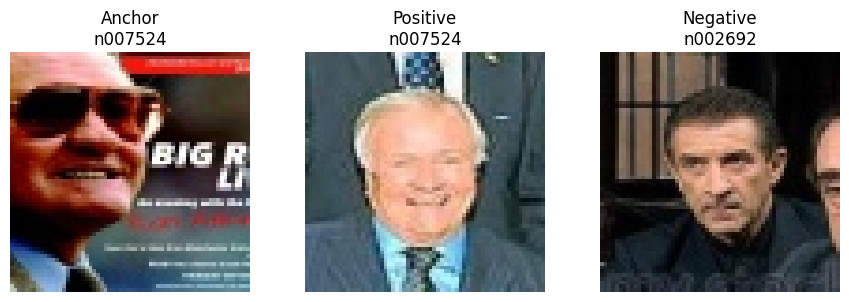

In [74]:
#OPTIONALLY display images of triplet set for verification
def show_triplet(anchor_path, positive_path, negative_path):
    anchor_img = Image.open(anchor_path)
    positive_img = Image.open(positive_path)
    negative_img = Image.open(negative_path)

    plt.figure(figsize=(9, 3))

    plt.subplot(1, 3, 1)
    plt.imshow(anchor_img)
    plt.title(f"Anchor\n{anchor_path.parent.name}")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(positive_img)
    plt.title(f"Positive\n{positive_path.parent.name}")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(negative_img)
    plt.title(f"Negative\n{negative_path.parent.name}")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


anchor_path, positive_path, negative_path = generate_triplet(valid_person_folders)
show_triplet(anchor_path, positive_path, negative_path)


In [75]:
# IMAGE PREPROCESSESING
IMAGE_SIZE = (160, 160)
def load_and_preprocess_image(image_path):
    #load the image from its file path
    image= Image.open(image_path)

    #makes sure each image has 3 colour channels
    image = image.convert("RGB")
    
    #resize images to be 160x160
    image = image.resize(IMAGE_SIZE)

    #converts image into numbers
    image_array = np.array(image)

    #converts pixel numbers to decimal for tensorflow
    image_array = image_array.astype("float32")

    #normalize pixel range from 0-255 to 0.0 - 1.0
    image_array = image_array / 255.0

    return image_array

anchor_img = load_and_preprocess_image(anchor_path)
positive_img = load_and_preprocess_image(positive_path)
negative_img = load_and_preprocess_image(negative_path)

print("Anchor image shape:", anchor_img.shape)
print("Positive image shape:", positive_img.shape)
print("Negative image shape:", negative_img.shape)

print("Anchor min pixel value:", anchor_img.min())
print("Anchor max pixel value:", anchor_img.max())

Anchor image shape: (160, 160, 3)
Positive image shape: (160, 160, 3)
Negative image shape: (160, 160, 3)
Anchor min pixel value: 0.0
Anchor max pixel value: 1.0


In [76]:
def load_triplet(anchor_path, positive_path, negative_path):
    anchor_image = load_and_preprocess_image(anchor_path)
    positive_image = load_and_preprocess_image(positive_path)
    negative_image = load_and_preprocess_image(negative_path)

    return anchor_image, positive_image, negative_image

anchor_image, positive_image, negative_image = load_triplet(
    anchor_path,
    positive_path,
    negative_path
)

print("Anchor image shape:", anchor_image.shape)
print("Positive image shape:", positive_image.shape)
print("Negative image shape:", negative_image.shape)

Anchor image shape: (160, 160, 3)
Positive image shape: (160, 160, 3)
Negative image shape: (160, 160, 3)


In [77]:
def generate_triplet_batch(valid_person_folders, batch_size):
    anchor_images = []
    positive_images = []
    negative_images = []
#lists to temporarily store the images for each section depending on batch size below


    for i in range(batch_size): #Creates amount of triples based on defined batch size batch=32 will be 32 anch, 32 pos, and 32 neg.
        anchor_path, positive_path, negative_path = generate_triplet(valid_person_folders)

        anchor_image, positive_image, negative_image = load_triplet(
            anchor_path,
            positive_path,
            negative_path
        )

        anchor_images.append(anchor_image)
        positive_images.append(positive_image)
        negative_images.append(negative_image)

    anchor_images = np.array(anchor_images)
    positive_images = np.array(positive_images)
    negative_images = np.array(negative_images)

    return anchor_images, positive_images, negative_images

batch_size = 8

anchor_batch, positive_batch, negative_batch = generate_triplet_batch(
    valid_person_folders,
    batch_size
)

print("Anchor batch shape:", anchor_batch.shape)
print("Positive batch shape:", positive_batch.shape)
print("Negative batch shape:", negative_batch.shape)



Anchor batch shape: (8, 160, 160, 3)
Positive batch shape: (8, 160, 160, 3)
Negative batch shape: (8, 160, 160, 3)


## Building the embedding model 

In [78]:
# buiding the embedding model

class L2Normalize(layers.Layer):
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)

    def get_config(self):
        config = super().get_config()
        return config


def build_embedding_model(input_shape=(160, 160, 3), embedding_size=128):
    inputs = layers.Input(shape=input_shape)
    #Set input layer with intput shape of 160,160, with rgb colour channel of 3

    x = layers.Conv2D(32, (3, 3), activation="relu", padding="same")(inputs)
    #conv layer to detect simple features like edges or curves.
    x = layers.MaxPooling2D((2, 2))(x)
    #maxpooling layers reduces image size smaller to focus on important features while reducing computation

    x = layers.Conv2D(64, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(128, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)

    x = layers.Conv2D(256, (3, 3), activation="relu", padding="same")(x)
    x = layers.MaxPooling2D((2, 2))(x)
    # as we do the deeper layers, the model begins to learn more complext features like face related features
    # like nose, eyes, mouth shape, or individual facial structures.

    x = layers.Flatten()(x)
#We then flatten image vectors from matrices into one long vector before going into dense layers
    x = layers.Dense(512, activation="relu")(x)

    x = layers.Dropout(0.3)(x)
#Dropout helps the model prevent overfitting - By randomly turning off neurons during training
# this then helps prevent the model from just memorising the training images, instead of learning the 
#underlying patterns

    embeddings = layers.Dense(embedding_size)(x)

    embeddings = L2Normalize(name="l2_normalized_embeddings")(embeddings)
#this normalizes the embedding vector to a length of 1

    model = Model(inputs, embeddings, name="face_embedding_model")

    return model

In [79]:
embedding_model = build_embedding_model()

embedding_model.summary()

Model: "face_embedding_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 160, 160, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 80, 80, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 80, 80, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 40, 40, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 40, 40, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 512)            │    13,107,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ l2_normalized_embeddings        │ (None, 128)            │             0 │
│ (L2Normalize)                   │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,561,792 (51.73 MB)

 Trainable params: 13,561,792 (51.73 MB)

 Non-trainable params: 0 (0.00 B)

In [80]:
anchor_embeddings = embedding_model(anchor_batch)
positive_embeddings = embedding_model(positive_batch)
negative_embeddings = embedding_model(negative_batch)

print("Anchor embeddings shape:", anchor_embeddings.shape)
print("Positive embeddings shape:", positive_embeddings.shape)
print("Negative embeddings shape:", negative_embeddings.shape)

Anchor embeddings shape: (8, 128)
Positive embeddings shape: (8, 128)
Negative embeddings shape: (8, 128)


In [81]:
#testing embeddings are successfully l2-normalized from before
embedding_norms = tf.norm(anchor_embeddings, axis=1)

print("Embedding norms:", embedding_norms.numpy())

Embedding norms: [1.         0.99999994 1.         1.         0.9999999  1.
 0.99999994 0.9999998 ]


In [82]:
def triplet_loss(anchor_embedding, positive_embedding, negative_embedding, margin=0.2):
    positive_distance = tf.reduce_sum(
        tf.square(anchor_embedding - positive_embedding),
        axis=1
    )

    negative_distance = tf.reduce_sum(
        tf.square(anchor_embedding - negative_embedding),
        axis=1
    )

    loss = positive_distance - negative_distance + margin

    loss = tf.maximum(loss, 0.0)

    loss = tf.reduce_mean(loss)

    return loss

anchor_embeddings = embedding_model(anchor_batch)
positive_embeddings = embedding_model(positive_batch)
negative_embeddings = embedding_model(negative_batch)

loss_value = triplet_loss(
    anchor_embeddings,
    positive_embeddings,
    negative_embeddings,
    margin=0.2
)

print("Triplet loss:", loss_value.numpy())

Triplet loss: 0.22132254


In [83]:
def calculate_distances(anchor_embedding, positive_embedding, negative_embedding):
    positive_distance = tf.reduce_sum(
        tf.square(anchor_embedding - positive_embedding),
        axis=1
    )

    negative_distance = tf.reduce_sum(
        tf.square(anchor_embedding - negative_embedding),
        axis=1
    )

    return positive_distance, negative_distance

positive_distances, negative_distances = calculate_distances(
    anchor_embeddings,
    positive_embeddings,
    negative_embeddings
)

print("Positive distances:", positive_distances.numpy())
print("Negative distances:", negative_distances.numpy())
print("Average positive distance:", tf.reduce_mean(positive_distances).numpy())
print("Average negative distance:", tf.reduce_mean(negative_distances).numpy())

Positive distances: [0.12946671 0.2087898  0.08819549 0.50302446 0.2753686  0.4094544
 0.0728785  0.15713155]
Negative distances: [0.17977837 0.1557279  0.24686237 0.33631447 0.16762674 0.14189279
 0.12795365 0.3175729 ]
Average positive distance: 0.2305387
Average negative distance: 0.20921615


In [84]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

In [85]:
@tf.function
def train_step(anchor_batch, positive_batch, negative_batch):
    with tf.GradientTape() as tape:
        anchor_embeddings = embedding_model(anchor_batch, training=True)
        positive_embeddings = embedding_model(positive_batch, training=True)
        negative_embeddings = embedding_model(negative_batch, training=True)

        loss = triplet_loss(
            anchor_embeddings,
            positive_embeddings,
            negative_embeddings,
            margin=0.2
        )

    gradients = tape.gradient(loss, embedding_model.trainable_variables)

    optimizer.apply_gradients(
        zip(gradients, embedding_model.trainable_variables)
    )

    return loss

In [86]:
#runnings the training for model
batch_size = 32
num_steps = 1000

loss_history = []

for step in range(num_steps):
    anchor_batch, positive_batch, negative_batch = generate_triplet_batch(
        valid_person_folders,
        batch_size
    )

    loss = train_step(anchor_batch, positive_batch, negative_batch)

    loss_history.append(loss.numpy())

    if (step + 1) % 10 == 0:
        recent_average_loss = np.mean(loss_history[-10:])
        print(
            f"Step {step + 1}/{num_steps}, "
            f"Recent Average Loss: {recent_average_loss:.4f}"
        )

Step 10/1000, Recent Average Loss: 0.1893
Step 20/1000, Recent Average Loss: 0.1884
Step 30/1000, Recent Average Loss: 0.1913
Step 40/1000, Recent Average Loss: 0.2014
Step 50/1000, Recent Average Loss: 0.1981
Step 60/1000, Recent Average Loss: 0.1967
Step 70/1000, Recent Average Loss: 0.1994
Step 80/1000, Recent Average Loss: 0.2053
Step 90/1000, Recent Average Loss: 0.2155
Step 100/1000, Recent Average Loss: 0.1963
Step 110/1000, Recent Average Loss: 0.2042
Step 120/1000, Recent Average Loss: 0.2018
Step 130/1000, Recent Average Loss: 0.2071
Step 140/1000, Recent Average Loss: 0.1953
Step 150/1000, Recent Average Loss: 0.1935
Step 160/1000, Recent Average Loss: 0.2063
Step 170/1000, Recent Average Loss: 0.1972
Step 180/1000, Recent Average Loss: 0.1914
Step 190/1000, Recent Average Loss: 0.2100
Step 200/1000, Recent Average Loss: 0.2025
Step 210/1000, Recent Average Loss: 0.2049
Step 220/1000, Recent Average Loss: 0.2047
Step 230/1000, Recent Average Loss: 0.2051
Step 240/1000, Recen

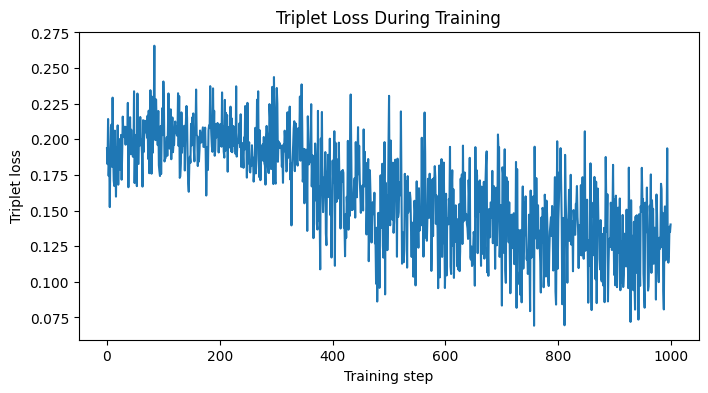

In [87]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("Training step")
plt.ylabel("Triplet loss")
plt.title("Triplet Loss During Training")
plt.show()

In [88]:
anchor_batch, positive_batch, negative_batch = generate_triplet_batch(
    valid_person_folders,
    batch_size=16
)

anchor_embeddings = embedding_model(anchor_batch, training=False)
positive_embeddings = embedding_model(positive_batch, training=False)
negative_embeddings = embedding_model(negative_batch, training=False)

positive_distances, negative_distances = calculate_distances(
    anchor_embeddings,
    positive_embeddings,
    negative_embeddings
)

print("Average positive distance:", tf.reduce_mean(positive_distances).numpy())
print("Average negative distance:", tf.reduce_mean(negative_distances).numpy())

Average positive distance: 0.20423284
Average negative distance: 0.24011166


In [89]:
for i in range(5):
    anchor_batch, positive_batch, negative_batch = generate_triplet_batch(
        valid_person_folders,
        batch_size=64
    )

    anchor_embeddings = embedding_model(anchor_batch, training=False)
    positive_embeddings = embedding_model(positive_batch, training=False)
    negative_embeddings = embedding_model(negative_batch, training=False)

    positive_distances, negative_distances = calculate_distances(
        anchor_embeddings,
        positive_embeddings,
        negative_embeddings
    )

    print(f"Run {i + 1}")
    print("Average positive distance:", tf.reduce_mean(positive_distances).numpy())
    print("Average negative distance:", tf.reduce_mean(negative_distances).numpy())
    print()

Run 1
Average positive distance: 0.20309913
Average negative distance: 0.36843675

Run 2
Average positive distance: 0.2059507
Average negative distance: 0.3567455

Run 3
Average positive distance: 0.19707368
Average negative distance: 0.34376377

Run 4
Average positive distance: 0.17861223
Average negative distance: 0.37431088

Run 5
Average positive distance: 0.20517114
Average negative distance: 0.3828208



In [90]:
from sklearn.metrics import roc_curve, auc, accuracy_score
import matplotlib.pyplot as plt

face_data_dir = Path("../../../data/datasets/face_data")

verification_dir = face_data_dir / "verification_data"
verification_pairs_path = face_data_dir / "verification_pairs_val.txt"

print("Verification image folder exists:", verification_dir.exists())
print("Verification pairs file exists:", verification_pairs_path.exists())

Verification image folder exists: True
Verification pairs file exists: True


In [91]:
def load_verification_pairs(pairs_file_path):
    pairs = []

    with open(pairs_file_path, "r") as file:
        for line in file:
            line = line.strip()

            if line == "":
                continue

            parts = line.split()

            image_path_1 = parts[0]
            image_path_2 = parts[1]
            label = int(parts[2])

            pairs.append((image_path_1, image_path_2, label))

    return pairs

verification_pairs = load_verification_pairs(verification_pairs_path)

print("Number of verification pairs:", len(verification_pairs))
print("First pair:", verification_pairs[0])

Number of verification pairs: 8805
First pair: ('verification_data/00041961.jpg', 'verification_data/00044353.jpg', 0)


In [92]:
def resolve_verification_image_path(image_path_text):
    image_path = Path(image_path_text)

    if image_path.exists():
        return image_path

    image_path_from_verification_dir = verification_dir / image_path_text

    if image_path_from_verification_dir.exists():
        return image_path_from_verification_dir

    image_path_from_face_data_dir = face_data_dir / image_path_text

    if image_path_from_face_data_dir.exists():
        return image_path_from_face_data_dir

    raise FileNotFoundError(f"Could not find image: {image_path_text}")

image_1_text, image_2_text, label = verification_pairs[0]

image_1_path = resolve_verification_image_path(image_1_text)
image_2_path = resolve_verification_image_path(image_2_text)

print("Image 1 path:", image_1_path)
print("Image 2 path:", image_2_path)
print("Label:", label)

Image 1 path: ../../../data/datasets/face_data/verification_data/00041961.jpg
Image 2 path: ../../../data/datasets/face_data/verification_data/00044353.jpg
Label: 0


In [93]:
def euclidean_distance(embedding_1, embedding_2):
    return np.sqrt(np.sum(np.square(embedding_1 - embedding_2)))


def cosine_similarity(embedding_1, embedding_2):
    dot_product = np.sum(embedding_1 * embedding_2)

    norm_1 = np.sqrt(np.sum(np.square(embedding_1)))
    norm_2 = np.sqrt(np.sum(np.square(embedding_2)))

    return dot_product / (norm_1 * norm_2)

In [94]:
def get_embedding_for_image(image_path):
    image = load_and_preprocess_image(image_path)

    image_batch = np.expand_dims(image, axis=0)

    embedding = embedding_model(image_batch, training=False)

    embedding = embedding.numpy()[0]

    return embedding

In [95]:
for i in range(10):
    image_1_text, image_2_text, label = verification_pairs[i]

    image_1_path = resolve_verification_image_path(image_1_text)
    image_2_path = resolve_verification_image_path(image_2_text)

    embedding_1 = get_embedding_for_image(image_1_path)
    embedding_2 = get_embedding_for_image(image_2_path)

    distance = euclidean_distance(embedding_1, embedding_2)
    cosine = cosine_similarity(embedding_1, embedding_2)

    print(f"Pair {i + 1}")
    print("Label:", label)
    print("Euclidean distance:", distance)
    print("Cosine similarity:", cosine)
    print()

Pair 1
Label: 0
Euclidean distance: 0.41653457
Cosine similarity: 0.9132496

Pair 2
Label: 1
Euclidean distance: 0.516926
Cosine similarity: 0.8663938

Pair 3
Label: 0
Euclidean distance: 1.0287517
Cosine similarity: 0.47083503

Pair 4
Label: 1
Euclidean distance: 0.49038085
Cosine similarity: 0.87976336

Pair 5
Label: 0
Euclidean distance: 0.44498444
Cosine similarity: 0.9009945

Pair 6
Label: 0
Euclidean distance: 0.65770745
Cosine similarity: 0.78371054

Pair 7
Label: 1
Euclidean distance: 0.5507859
Cosine similarity: 0.8483175

Pair 8
Label: 0
Euclidean distance: 0.5436111
Cosine similarity: 0.85224354

Pair 9
Label: 0
Euclidean distance: 0.45046338
Cosine similarity: 0.89854145

Pair 10
Label: 1
Euclidean distance: 0.47370955
Cosine similarity: 0.8877996



In [96]:
def evaluate_verification_pairs(verification_pairs):
    true_labels = []

    euclidean_scores = []
    cosine_scores = []

    for i, (image_1_text, image_2_text, label) in enumerate(verification_pairs):
        image_1_path = resolve_verification_image_path(image_1_text)
        image_2_path = resolve_verification_image_path(image_2_text)

        embedding_1 = get_embedding_for_image(image_1_path)
        embedding_2 = get_embedding_for_image(image_2_path)

        distance = euclidean_distance(embedding_1, embedding_2)
        cosine = cosine_similarity(embedding_1, embedding_2)

        # For ROC/AUC, higher score should mean "more likely same person".
        euclidean_score = -distance

        true_labels.append(label)
        euclidean_scores.append(euclidean_score)
        cosine_scores.append(cosine)

        if (i + 1) % 500 == 0:
            print(f"Processed {i + 1}/{len(verification_pairs)} pairs")

    return (
        np.array(true_labels),
        np.array(euclidean_scores),
        np.array(cosine_scores)
    )

In [97]:
true_labels, euclidean_scores, cosine_scores = evaluate_verification_pairs(
    verification_pairs
)

Processed 500/8805 pairs
Processed 1000/8805 pairs
Processed 1500/8805 pairs
Processed 2000/8805 pairs
Processed 2500/8805 pairs
Processed 3000/8805 pairs
Processed 3500/8805 pairs
Processed 4000/8805 pairs
Processed 4500/8805 pairs
Processed 5000/8805 pairs
Processed 5500/8805 pairs
Processed 6000/8805 pairs
Processed 6500/8805 pairs
Processed 7000/8805 pairs
Processed 7500/8805 pairs
Processed 8000/8805 pairs
Processed 8500/8805 pairs


In [98]:
def calculate_auc_results(true_labels, scores, metric_name):
    fpr, tpr, thresholds = roc_curve(true_labels, scores)

    auc_score = auc(fpr, tpr)

    print(f"{metric_name} AUC:", auc_score)

    return fpr, tpr, thresholds, auc_score

euclidean_fpr, euclidean_tpr, euclidean_thresholds, euclidean_auc = calculate_auc_results(
    true_labels,
    euclidean_scores,
    "Euclidean"
)

cosine_fpr, cosine_tpr, cosine_thresholds, cosine_auc = calculate_auc_results(
    true_labels,
    cosine_scores,
    "Cosine"
)

Euclidean AUC: 0.7267176447209842
Cosine AUC: 0.7267176705283016


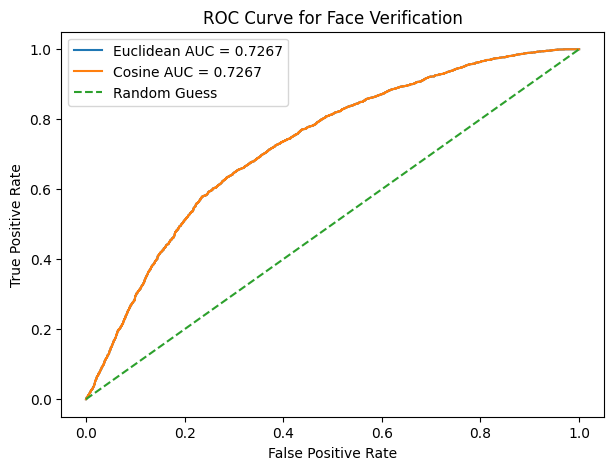

In [99]:
plt.figure(figsize=(7, 5))

plt.plot(euclidean_fpr, euclidean_tpr, label=f"Euclidean AUC = {euclidean_auc:.4f}")
plt.plot(cosine_fpr, cosine_tpr, label=f"Cosine AUC = {cosine_auc:.4f}")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random Guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Face Verification")
plt.legend()
plt.show()

In [100]:
def find_best_threshold(true_labels, scores, thresholds):
    best_accuracy = 0
    best_threshold = None

    for threshold in thresholds:
        predictions = []

        for score in scores:
            if score >= threshold:
                predictions.append(1)
            else:
                predictions.append(0)

        accuracy = accuracy_score(true_labels, predictions)

        if accuracy > best_accuracy:
            best_accuracy = accuracy
            best_threshold = threshold

    return best_threshold, best_accuracy

In [102]:
best_euclidean_threshold, best_euclidean_accuracy = find_best_threshold(
    true_labels,
    euclidean_scores,
    euclidean_thresholds
)

best_cosine_threshold, best_cosine_accuracy = find_best_threshold(
    true_labels,
    cosine_scores,
    cosine_thresholds
)

print("Best Euclidean score threshold:", best_euclidean_threshold)
print("Best Euclidean verification accuracy:", best_euclidean_accuracy)

print("Best Cosine threshold:", best_cosine_threshold)
print("Best Cosine verification accuracy:", best_cosine_accuracy)

embedding_model.save("../../../src/panopticon/model_weights/metric_learning_current_after_extra_training.keras")

Best Euclidean score threshold: -0.4712332487106323
Best Euclidean verification accuracy: 0.6748438387279955
Best Cosine threshold: 0.8889695405960083
Best Cosine verification accuracy: 0.6748438387279955
